In [ ]:
from dotenv import load_dotenv

load_dotenv()

## No memory

In [ ]:
from langchain.agents import create_agent


agent = create_agent(
    "gpt-5-nano"
)

In [ ]:
from langchain.messages import HumanMessage

question = HumanMessage(content="Hello my name is Seán and my favourite colour is green")

response = agent.invoke(
    {"messages": [question]} 
)

In [ ]:
from pprint import pprint

pprint(response)

In [ ]:
question = HumanMessage(content="What's my favourite colour?")

response = agent.invoke(
    {"messages": [question]} 
)

pprint(response)

## Memory

In [13]:
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
### na atual versão, não usamos o create_react_agent mais, e sim, sua versão mais atual 
from langchain.agents import create_agent 
from pprint import pprint


model = init_chat_model(
    model="openai/gpt-oss-20b",
    model_provider="groq",
    temperature=0.50
)


## não irei utilizar tools aqui, a finalidade aqui é entender como o checkpointer funciona
## checkpointer=InMemorySaver() crio uma memoria do tipo short-term
## InMemorySaver() é um checkpointer que guarda os checkpoints do agente na memoria do processo do python
## Pode salvar o HumamMessage, AIMessage 

memory = InMemorySaver()

agent = create_agent(
    model=model,
    tools=[],
    checkpointer=memory,  # Salva e recupera o estado do agente em memória por thread.
)

config = {
    "configurable": {
        "thread_id": "usuario-123" # preciso ter essa thread, ela funciona como um id para manter a conversa salva por quem esta usando na short memory
    }
}


In [11]:
pergunta1 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Meu nome é Mateus."
            }
        ]
    },
    config=config
)

print(pergunta1)

{'messages': [HumanMessage(content='Qual é o meu nome?', additional_kwargs={}, response_metadata={}, id='b1be1772-1096-4434-901c-18581c2fbd2f'), AIMessage(content='Não tenho como saber qual é o seu nome a menos que você me diga. Se quiser, pode me contar!', additional_kwargs={'reasoning_content': 'User asks: "Qual é o meu nome?" in Portuguese. They want to know their name. We don\'t know their name. We must respond that we don\'t know. We can ask them. According to policy, we cannot reveal personal info. We can say we don\'t know.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 77, 'total_tokens': 166, 'completion_time': 0.090093323, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.00366816, 'prompt_tokens_details': None, 'queue_time': 0.190578836, 'total_time': 0.093761483}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_prov

In [12]:
pergunta2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Qual é o meu nome?"
            }
        ]
    },
    config=config
)

pprint(pergunta2)


{'messages': [HumanMessage(content='Qual é o meu nome?', additional_kwargs={}, response_metadata={}, id='b1be1772-1096-4434-901c-18581c2fbd2f'),
              AIMessage(content='Não tenho como saber qual é o seu nome a menos que você me diga. Se quiser, pode me contar!', additional_kwargs={'reasoning_content': 'User asks: "Qual é o meu nome?" in Portuguese. They want to know their name. We don\'t know their name. We must respond that we don\'t know. We can ask them. According to policy, we cannot reveal personal info. We can say we don\'t know.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 77, 'total_tokens': 166, 'completion_time': 0.090093323, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.00366816, 'prompt_tokens_details': None, 'queue_time': 0.190578836, 'total_time': 0.093761483}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': Non

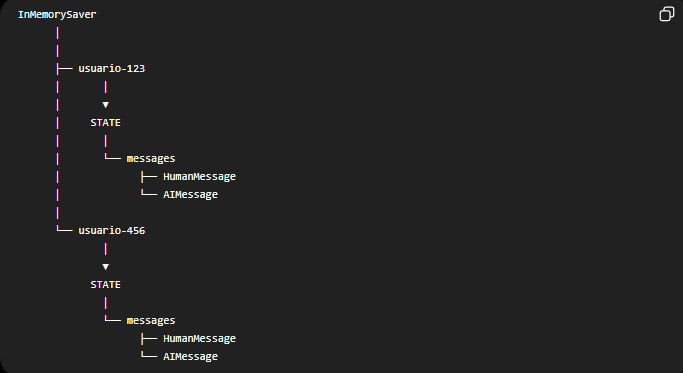

In [ ]:
###### o InMemorySaver pode ser interpretado didaticamente como um gerenciador de checkpoints do agente
###### ela mantem estados separados atravez do thread_id
###### para cada agente, deve ter seu proprio thread_id, pois, assim, ele vai lembrar de cada conversa do seu respectivo usuario 
###### quando eu configuro o config {"configurable"....} -> estou falando pro agente executar a conversa dentro desse thread chamado 'usuario-123'
###### ou seja, dentro do inMemorySaver() temos os thread_id e cada um possui seu STATE com messages, como AIMessage, HumanMessage.....